In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account
import numpy as np

df = pd.read_csv("../project/01_data/raw/gdelt_raw.csv")

In [27]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str))

In [29]:
# 'AvgTone' 컬럼의 값이 -3 이하인 행만 추출
negative_events_df = df[df['AvgTone'] <= -2]

print(f"전체 사건 수: {len(df)}건")
print(f"톤 -3 이하 사건 수: {len(negative_events_df)}건")

# 결과 확인
negative_events_df.head()

전체 사건 수: 11901건
톤 -3 이하 사건 수: 7277건


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
1,2022-10-16,150,-7.2,5,-2.020202,4,39.9289,116.3880,https://asia.nikkei.com/Politics/China-s-party...
4,2022-06-12,192,-9.5,2,-5.449190,4,39.9289,116.3880,https://www.news24.com/news24/World/News/we-wi...
5,2022-06-12,190,-10.0,8,-4.689480,3,38.8951,-77.0364,https://www.mvariety.com/news/us-and-allies-tr...
6,2022-06-12,202,-10.0,8,-6.225681,4,39.9044,116.3910,https://focustaiwan.tw/society/202206120012
7,2022-06-12,190,-10.0,10,-3.930717,4,39.9289,116.3880,https://www.sbs.com.au/news/article/richard-ma...


In [30]:
# 1. 톤이 -3 이하인 데이터 중 언급 횟수(NumMentions) 기준 내림차순 정렬
sorted_df = negative_events_df.sort_values(by='NumMentions', ascending=False)

# 2. 주요 수치형 컬럼에 대한 기술 통계량 (개수, 평균, 표준편차, 사분위수 등)
stats = negative_events_df[['GoldsteinScale', 'NumMentions', 'AvgTone']].describe()

print(" [상위 5개 사건 확인] ")
display(sorted_df.head(5))

print("\n [주요 지표 통계 요약] ")
display(stats)

 [상위 5개 사건 확인] 


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
6475,2022-07-30,150,-7.2,1465,-2.146788,4,39.9289,116.388,https://www.sfgate.com/news/article/China-anno...
7203,2022-08-07,190,-10.0,1420,-4.161978,4,39.9289,116.388,https://www.sfgate.com/news/article/China-keep...
1601,2022-08-08,150,-7.2,1242,-4.208492,4,-35.2833,149.217,https://www.ourmidland.com/news/article/China-...
9268,2020-12-31,151,-7.2,1190,-3.208156,4,24.0000,119.000,https://www.sfgate.com/news/article/China-accu...
2993,2025-02-27,193,-10.0,1026,-3.964070,4,39.9289,116.388,https://www.ksat.com/news/world/2025/02/27/tai...



 [주요 지표 통계 요약] 


,GoldsteinScale,NumMentions,AvgTone
count,7277.000000,7277.000000,7277.000000
mean,-8.826907,13.527278,-3.917499
std,1.343655,50.347197,1.588656
min,-10.000000,1.000000,-18.181818
25%,-10.000000,2.000000,-4.697962
50%,-10.000000,5.000000,-3.544960
75%,-7.200000,10.000000,-2.735671
max,-7.200000,1465.000000,-2.000000


In [31]:
import pandas as pd

# 1. 사용자가 제공한 실제 주요 사건 리스트
event_list = [
    {'start': 20251229, 'end': 20251230, 'event_name': '다구역 포위형 군사활동 확대 (25.12)'},
    {'start': 20241014, 'end': 20241014, 'event_name': 'Joint Sword-2024B (24.10)'},
    {'start': 20240523, 'end': 20240524, 'event_name': 'Joint Sword-2024A (24.05)'},
    {'start': 20240520, 'end': 20240520, 'event_name': 'Lai Ching-te 취임 (24.05)'},
    {'start': 20240113, 'end': 20240113, 'event_name': '대만 라이칭더 당선 (24.01)'},
    {'start': 20230812, 'end': 20230818, 'event_name': '라이칭더 미국 경유 및 중국 반응 (23.08)'},
    {'start': 20230405, 'end': 20230410, 'event_name': 'Shandong 동부 전개 & Joint Sword (23.04)'},
    {'start': 20230405, 'end': 20230405, 'event_name': 'Tsai-McCarthy 회동 (23.04)'},
    {'start': 20220804, 'end': 20220810, 'event_name': '대만 포위 실사격 훈련 (22.08)'},
    {'start': 20220802, 'end': 20220803, 'event_name': 'Pelosi 대만 방문 (22.08)'},
    {'start': 20211001, 'end': 20211004, 'event_name': '역대 최대 ADIZ 진입 (21.10)'},
    {'start': 20210326, 'end': 20210326, 'event_name': '미-대만 해경 협력 및 중국 반발 (21.03)'},
    {'start': 20200917, 'end': 20200919, 'event_name': '미국 국무차관 대만 방문 (20.09)'},
    {'start': 20200809, 'end': 20200812, 'event_name': '미국 보건장관 대만 방문 (20.08)'},
    {'start': 20250401, 'end': 20250402, 'event_name': 'Strait Thunder-2025A (25.04)'},
    {'start': 20190601, 'end': 20191231, 'event_name': '홍콩 시위 이후 양안 긴장 (19.06~12)'},
    {'start': 20190331, 'end': 20190331, 'event_name': '대만해협 중간선 침범 (19.03)'},
    {'start': 20180418, 'end': 20180418, 'event_name': '대만해협 실사격 훈련 (18.04)'},
    {'start': 20161101, 'end': 20171231, 'event_name': '폭격기·항모 순환훈련 확대 (16.11~17.12)'},
    {'start': 20160520, 'end': 20160520, 'event_name': '차이잉원 취임 (16.05)'},
    {'start': 20131123, 'end': 20131123, 'event_name': '동중국해 ADIZ 일방 선포 (13.11)'}
]

# 🌟 핵심 수정 포인트: SQLDATE 컬럼을 표준 Pandas Datetime으로 강제 변환
# (내부적으로 꼬여있는 날짜 포맷을 Timestamp가 이해할 수 있게 초기화합니다)
negative_events_df['SQLDATE'] = pd.to_datetime(negative_events_df['SQLDATE'], errors='coerce')

# 혹시 모를 Timezone 정보가 섞여 있다면 제거하여 비교 기준을 통일합니다.
if negative_events_df['SQLDATE'].dt.tz is not None:
    negative_events_df['SQLDATE'] = negative_events_df['SQLDATE'].dt.tz_localize(None)

match_results = []

for event in event_list:
    # 비교할 날짜도 Pandas Datetime 형식으로 변환
    start_date = pd.to_datetime(str(event['start']), format='%Y%m%d')
    end_date = pd.to_datetime(str(event['end']), format='%Y%m%d')
    
    # 정상적으로 불리언 인덱싱 작동
    mask = (negative_events_df['SQLDATE'] >= start_date) & (negative_events_df['SQLDATE'] <= end_date)
    matched_data = negative_events_df[mask]
    
    match_results.append({
        'Event Name': event['event_name'],
        'Start Date': start_date.strftime('%Y-%m-%d'), 
        'End Date': end_date.strftime('%Y-%m-%d'),
        'GDELT_Count': len(matched_data),
        'Max_Mentions': matched_data['NumMentions'].max() if len(matched_data) > 0 else 0,
        'Avg_Tone': round(matched_data['AvgTone'].mean(), 2) if len(matched_data) > 0 else None
    })

# 3. 데이터프레임으로 변환 후 출력
match_df = pd.DataFrame(match_results)

# 가장 많이 언급된(Max_Mentions) 순서대로 정렬
match_df_sorted = match_df.sort_values(by=['Max_Mentions', 'GDELT_Count'], ascending=[False, False])

display(match_df_sorted)

C:\Users\Jua\AppData\Local\Temp\ipykernel_3828\413120072.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_events_df['SQLDATE'] = pd.to_datetime(negative_events_df['SQLDATE'], errors='coerce')


,Event Name,Start Date,End Date,GDELT_Count,Max_Mentions,Avg_Tone
8,대만 포위 실사격 훈련 (22.08),2022-08-04,2022-08-10,454,1420,-3.67
10,역대 최대 ADIZ 진입 (21.10),2021-10-01,2021-10-04,77,840,-4.12
9,Pelosi 대만 방문 (22.08),2022-08-02,2022-08-03,99,642,-3.37
6,Shandong 동부 전개 & Joint Sword (23.04),2023-04-05,2023-04-10,187,310,-2.95
2,Joint Sword-2024A (24.05),2024-05-23,2024-05-24,65,298,-3.83
19,차이잉원 취임 (16.05),2016-05-20,2016-05-20,1,239,-3.21
14,Strait Thunder-2025A (25.04),2025-04-01,2025-04-02,71,214,-4.30
0,다구역 포위형 군사활동 확대 (25.12),2025-12-29,2025-12-30,81,208,-3.53
15,홍콩 시위 이후 양안 긴장 (19.06~12),2019-06-01,2019-12-31,175,198,-4.37
17,대만해협 실사격 훈련 (18.04),2018-04-18,2018-04-18,10,184,-4.97


### 📈 [GDELT 데이터 포착 비율 요약] ###
총 검증 사건 수 : 21건
✅ 포착된 사건  : 19건 (90.5%)
❌ 미포착 사건  : 2건 (9.5%)

### 🔍 [미포착 사건 리스트] ###


,Event Name,Start Date,End Date
3,Lai Ching-te 취임 (24.05),2024-05-20,2024-05-20
20,동중국해 ADIZ 일방 선포 (13.11),2013-11-23,2013-11-23


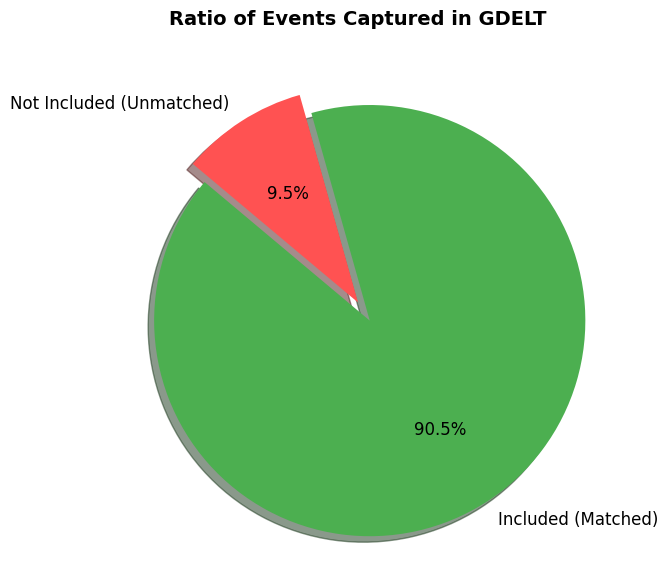

In [32]:
import matplotlib.pyplot as plt

# 1. 포함(Matched) 및 미포함(Unmatched) 사건 수 계산
# GDELT_Count가 1 이상이면 포착된 것으로 간주합니다.
total_events = len(match_df)
matched_events = len(match_df[match_df['GDELT_Count'] > 0])
unmatched_events = len(match_df[match_df['GDELT_Count'] == 0])

# 2. 비율(%) 계산
matched_ratio = (matched_events / total_events) * 100
unmatched_ratio = (unmatched_events / total_events) * 100

# 3. 텍스트 요약 출력
print("### 📈 [GDELT 데이터 포착 비율 요약] ###")
print(f"총 검증 사건 수 : {total_events}건")
print(f"✅ 포착된 사건  : {matched_events}건 ({matched_ratio:.1f}%)")
print(f"❌ 미포착 사건  : {unmatched_events}건 ({unmatched_ratio:.1f}%)\n")

# 4. 미포착 사건 리스트 따로 뽑아보기 (원인 분석용)
if unmatched_events > 0:
    print("### 🔍 [미포착 사건 리스트] ###")
    unmatched_df = match_df[match_df['GDELT_Count'] == 0]
    display(unmatched_df[['Event Name', 'Start Date', 'End Date']])

# 5. 파이 차트 시각화 (글꼴 깨짐 방지를 위해 영문 라벨 사용)
labels = ['Included (Matched)', 'Not Included (Unmatched)']
sizes = [matched_events, unmatched_events]
colors = ['#4CAF50', '#FF5252'] # 초록(포함), 빨강(미포함)
explode = (0.1, 0) # 파이 조각 분리 효과

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 12})
plt.title('Ratio of Events Captured in GDELT', fontsize=14, fontweight='bold')
plt.show()

In [33]:
import pandas as pd

# 1. 리스트에 있는 사건 기간을 개별 '일(Day)' 단위로 풀어서 집합(Set)으로 만듭니다.
# 겹치는 날짜(예: 특정 기간 내 또 다른 사건 발생)가 있을 수 있으므로 set을 사용하여 중복을 제거합니다.
event_dates = set()
for event in event_list:
    start_date = pd.to_datetime(str(event['start']), format='%Y%m%d')
    end_date = pd.to_datetime(str(event['end']), format='%Y%m%d')
    # start부터 end까지의 연속된 날짜를 생성하여 추가
    dates_in_event = pd.date_range(start=start_date, end=end_date)
    event_dates.update(dates_in_event)

# 2. 전체 데이터 기간(Timeframe) 설정
# 최초 쿼리에서 2013-04-01 이후 데이터를 가져오셨으므로 이를 시작일로 잡습니다.
start_of_data = pd.to_datetime('2013-04-01')
# GDELT 데이터의 가장 마지막 날짜를 종료일로 잡습니다. (시간(시분초)은 normalize()로 제거)
end_of_data = negative_events_df['SQLDATE'].max().normalize() 
total_days = (end_of_data - start_of_data).days + 1

# 분석 기간(2013.04 ~ 데이터 마지막 날) 내에 있는 사건 날짜만 필터링 (미래 날짜인 2025년 계획 등은 제외됨)
valid_event_dates = [d for d in event_dates if start_of_data <= d <= end_of_data]
num_event_days = len(valid_event_dates)
num_non_event_days = total_days - num_event_days

print("### 1️ [전체 기간 기준: 사건 발생일 vs 평시] ###")
print(f"총 분석 기간 ({start_of_data.strftime('%Y-%m-%d')} ~ {end_of_data.strftime('%Y-%m-%d')}) : {total_days}일")
print(f" 사건 리스트에 포함된 날짜 수 : {num_event_days}일")
print(f" 사건 리스트에 포함되지 않은 날 (평시) : {num_non_event_days}일\n")

# 3. GDELT 데이터 기준으로 세부 분석
# GDELT에서 톤 -3 이하의 기사가 하나라도 발생한 고유 날짜들
gdelt_active_dates = set(negative_events_df['SQLDATE'].dt.normalize())

# GDELT가 감지한 날짜 중, 실제 사건 리스트와 겹치는 날 vs 안 겹치는 날
gdelt_matched_days = gdelt_active_dates.intersection(event_dates)
gdelt_unmatched_days = gdelt_active_dates - event_dates

print("### 2️ [GDELT 고위험 감지일 기준 분석] ###")
print(f"GDELT 고위험 데이터(-3 톤 이하)가 발생한 총 날짜 수 : {len(gdelt_active_dates)}일")
print(f" 위기 사건 리스트 기간과 일치하는 날 : {len(gdelt_matched_days)}일")
print(f" 리스트엔 없지만 GDELT가 위험을 감지한 날 : {len(gdelt_unmatched_days)}일")

### 1️ [전체 기간 기준: 사건 발생일 vs 평시] ###
총 분석 기간 (2013-04-01 ~ 2026-05-11) : 4789일
 사건 리스트에 포함된 날짜 수 : 687일
 사건 리스트에 포함되지 않은 날 (평시) : 4102일

### 2️ [GDELT 고위험 감지일 기준 분석] ###
GDELT 고위험 데이터(-3 톤 이하)가 발생한 총 날짜 수 : 1662일
 위기 사건 리스트 기간과 일치하는 날 : 214일
 리스트엔 없지만 GDELT가 위험을 감지한 날 : 1448일
